In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HepatitisCdata.csv to HepatitisCdata.csv


In [ ]:
#Reading Dataset
import pandas as pd
import io
df = pd.read_csv(io.BytesIO(uploaded['HepatitisCdata.csv']))# Dataset is now stored in a Pandas Dataframe

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import GaussianNB

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier, BaggingClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, matthews_corrcoef


# Drop rows with any missing values
df.dropna(inplace=True)

# Method 1: Using shape
num_columns = df.shape[1]
print("Number of columns:", num_columns)

# Method 2: Using len on columns
print("Number of columns:", len(df.columns))

# Optional: List all column names
print("Column names:", df.columns.tolist())

# Encode categorical variables
le_category = LabelEncoder()
df['Category'] = le_category.fit_transform(df['Category'])

le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])

# Features and target
X = df.drop(columns=['Category'])
y = df['Category']

print(X)



Number of columns: 13
Number of columns: 13
Column names: ['Category', 'Age', 'Sex', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']
     Age  Sex   ALB    ALP   ALT    AST   BIL    CHE  CHOL   CREA    GGT  PROT
0     32    1  38.5   52.5   7.7   22.1   7.5   6.93  3.23  106.0   12.1  69.0
1     32    1  38.5   70.3  18.0   24.7   3.9  11.17  4.80   74.0   15.6  76.5
2     32    1  46.9   74.7  36.2   52.6   6.1   8.84  5.20   86.0   33.2  79.3
3     32    1  43.2   52.0  30.6   22.6  18.9   7.33  4.74   80.0   33.8  75.7
4     32    1  39.2   74.1  32.6   24.8   9.6   9.15  4.32   76.0   29.9  68.7
..   ...  ...   ...    ...   ...    ...   ...    ...   ...    ...    ...   ...
608   58    0  34.0   46.4  15.0  150.0   8.0   6.26  3.98   56.0   49.7  80.6
609   59    0  39.0   51.3  19.6  285.8  40.0   5.77  4.51  136.1  101.1  70.5
610   62    0  32.0  416.6   5.9  110.3  50.0   5.57  6.30   55.7  650.9  68.5
611   64    0  24.0  102.8   2.9   44.4  20.0   1.54

In [ ]:
# ============================
# Train-Test Split
# ============================
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE

# Split first (before feature selection and SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=1,
    stratify=y
)

# ============================
# Feature Selection on TRAIN only
# ============================
selector = SelectKBest(
    score_func=f_classif,
    k=9
)

X_train_selected = selector.fit_transform(
    X_train,
    y_train
)

X_test_selected = selector.transform(
    X_test
)

selected_features = X.columns[
    selector.get_support()
]

print("Selected Features:")
print(list(selected_features))

# ====================================================
# Save copies BEFORE SMOTE (for PCA visualization)
# ====================================================
X_train_before_smote = X_train_selected.copy()
y_train_before_smote = y_train.copy()

# ============================
# Apply SMOTE on TRAIN only
# ============================
sm = SMOTE(
    random_state=1,
    k_neighbors=3
)

X_train_selected, y_train = sm.fit_resample(
    X_train_selected,
    y_train
)

# ====================================================
# Save copies AFTER SMOTE (for PCA visualization)
# ====================================================
X_train_after_smote = X_train_selected.copy()
y_train_after_smote = y_train.copy()

print("\n" + "="*60)
print("NUMBER OF SAMPLES IN EACH CLASS")
print("="*60)

summary = pd.DataFrame({
    'Training Before SMOTE':
        y_train_before_smote.value_counts().sort_index(),

    'Training After SMOTE':
        y_train_after_smote.value_counts().sort_index(),

    'Testing Set':
        y_test.value_counts().sort_index()
})

# Optional: Replace with your class names
summary.index = [
    'Blood Donor',
    'Suspect Blood Donor',
    'Hepatitis',
    'Fibrosis',
    'Cirrhosis'
]

print(summary)

print("\n" + "="*60)
print("TOTAL NUMBER OF SAMPLES")
print("="*60)

print(f"Training samples before SMOTE : {len(y_train_before_smote)}")
print(f"Training samples after SMOTE  : {len(y_train_after_smote)}")
print(f"Testing samples               : {len(y_test)}")

Selected Features:
['ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'GGT', 'PROT']

NUMBER OF SAMPLES IN EACH CLASS
                     Training Before SMOTE  Training After SMOTE  Testing Set
Blood Donor                            368                   368          158
Suspect Blood Donor                      5                   368            2
Hepatitis                               14                   368            6
Fibrosis                                 8                   368            4
Cirrhosis                               17                   368            7

TOTAL NUMBER OF SAMPLES
Training samples before SMOTE : 412
Training samples after SMOTE  : 1840
Testing samples               : 177


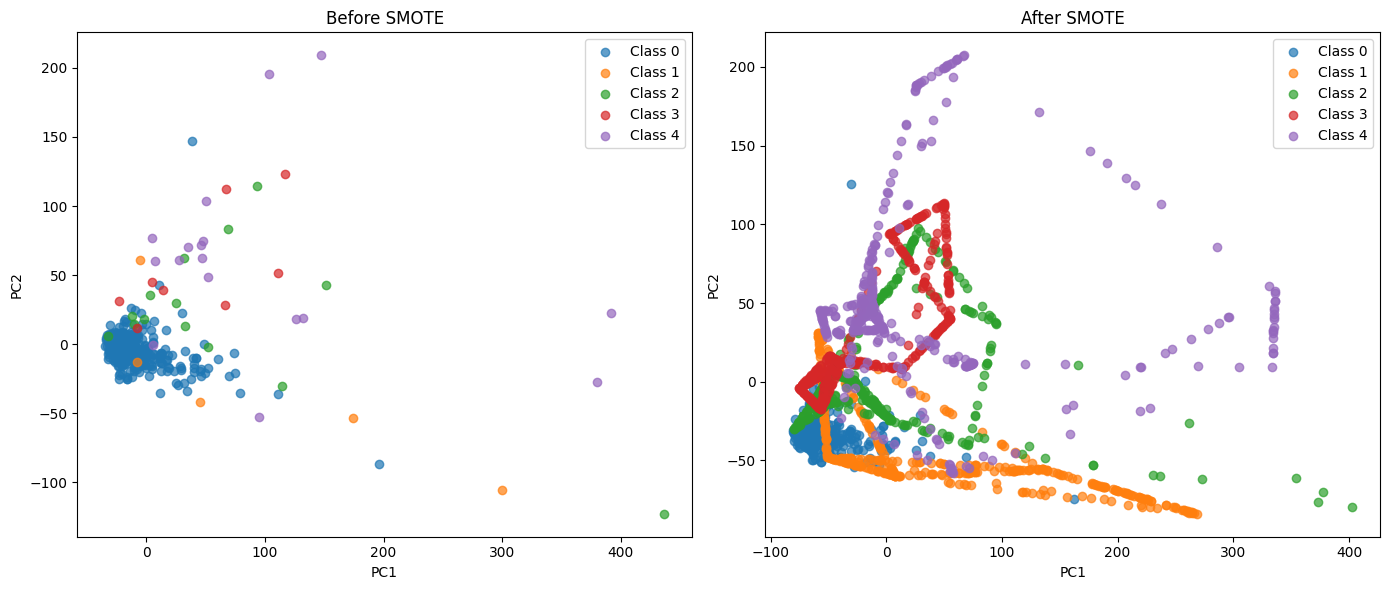

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2)

X_before = pca.fit_transform(X_train_before_smote)
X_after = pca.fit_transform(X_train_after_smote)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,6)
)

# Before SMOTE
for c in np.unique(y_train_before_smote):
    axes[0].scatter(
        X_before[
            y_train_before_smote == c, 0
        ],
        X_before[
            y_train_before_smote == c, 1
        ],
        label=f'Class {c}',
        alpha=0.7
    )

axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# After SMOTE
for c in np.unique(y_train_after_smote):
    axes[1].scatter(
        X_after[
            y_train_after_smote == c, 0
        ],
        X_after[
            y_train_after_smote == c, 1
        ],
        label=f'Class {c}',
        alpha=0.7
    )

axes[1].set_title('After SMOTE')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
plt.show()

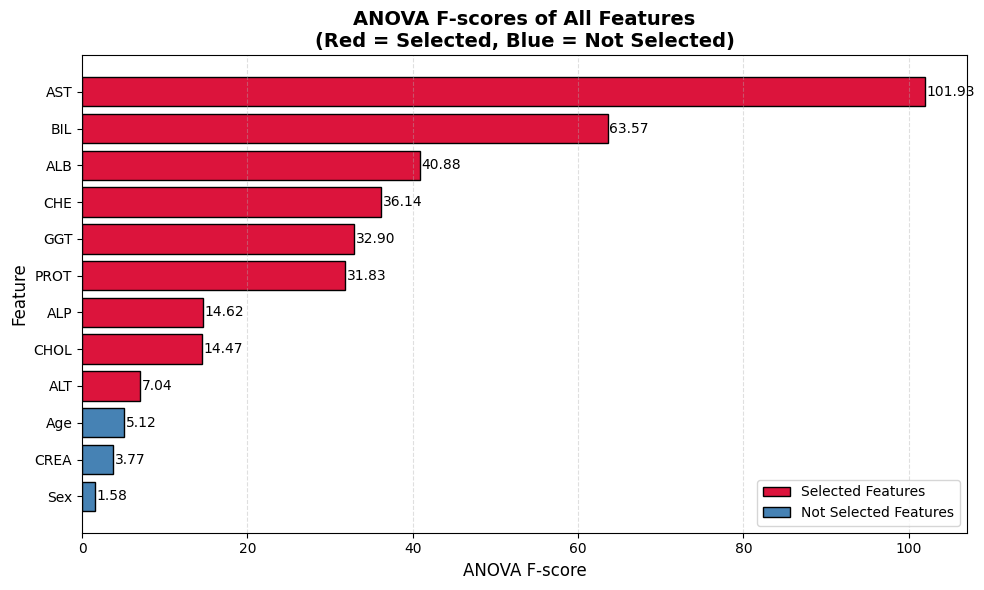

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get F-scores of all features
scores = selector.scores_
feature_names = X.columns

# Selected features
selected_features = list(
    X.columns[selector.get_support()]
)

# Create dataframe
f_scores = pd.DataFrame({
    'Feature': feature_names,
    'F-score': scores
})

# Sort features by F-score
f_scores = f_scores.sort_values(
    by='F-score',
    ascending=False
)

# Assign colors
colors = [
    'crimson' if feature in selected_features
    else 'steelblue'
    for feature in f_scores['Feature']
]

# Plot
plt.figure(figsize=(10, 6))

bars = plt.barh(
    f_scores['Feature'],
    f_scores['F-score'],
    color=colors,
    edgecolor='black'
)

# Add F-score values
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center',
        fontsize=10
    )

# Highest score on top
plt.gca().invert_yaxis()

plt.xlabel('ANOVA F-score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(
    'ANOVA F-scores of All Features\n(Red = Selected, Blue = Not Selected)',
    fontsize=14,
    fontweight='bold'
)

# Create legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='crimson',
          edgecolor='black',
          label='Selected Features'),
    Patch(facecolor='steelblue',
          edgecolor='black',
          label='Not Selected Features')
]

plt.legend(
    handles=legend_elements,
    loc='lower right'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)
import pandas as pd
import numpy as np

# Modify according to your class labels
class_names = [
    'Blood Donor',
    'Suspect Blood Donor',
    'Hepatitis',
    'Fibrosis',
    'Cirrhosis'
]

# Macro specificity
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specificity_per_class = []

    for i in range(len(cm)):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)

        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificity_per_class.append(specificity)

    return np.mean(specificity_per_class)


# Class-wise specificity
def classwise_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specificity = []

    for i in range(len(cm)):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)

        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificity.append(spec)

    return specificity


# Evaluate models
for name, model in models.items():

    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)

    # Overall metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    spec = specificity_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    print("\n" + "="*80)
    print(name)
    print("="*80)

    print(f"Accuracy   : {acc:.4f}")
    print(f"Precision  : {prec:.4f}")
    print(f"Sensitivity: {rec:.4f}")
    print(f"Specificity: {spec:.4f}")
    print(f"F1 Score   : {f1:.4f}")
    print(f"MCC        : {mcc:.4f}")

    # Classification report
    report = classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()

    report_df = report_df.loc[
        class_names,
        ['precision', 'recall', 'f1-score', 'support']
    ]

    # Add class-wise specificity
    report_df['specificity'] = classwise_specificity(
        y_test,
        y_pred
    )

    report_df.columns = [
        'Precision',
        'Sensitivity',
        'F1-Score',
        'Support',
        'Specificity'
    ]

    print("\nClass-wise Results:")
    print(report_df.round(4))


Random Forest
Accuracy   : 0.9322
Precision  : 0.6872
Sensitivity: 0.5297
Specificity: 0.9392
F1 Score   : 0.5867
MCC        : 0.6290

Class-wise Results:
                     Precision  Sensitivity  F1-Score  Support  Specificity
Blood Donor             0.9691       0.9937    0.9812    158.0       0.7368
Suspect Blood Donor     1.0000       0.5000    0.6667      2.0       1.0000
Hepatitis               0.3333       0.3333    0.3333      6.0       0.9766
Fibrosis                0.3333       0.2500    0.2857      4.0       0.9884
Cirrhosis               0.8000       0.5714    0.6667      7.0       0.9941

Gradient Boosting
Accuracy   : 0.9492
Precision  : 0.8027
Sensitivity: 0.6464
Specificity: 0.9521
F1 Score   : 0.7009
MCC        : 0.7287

Class-wise Results:
                     Precision  Sensitivity  F1-Score  Support  Specificity
Blood Donor             0.9752       0.9937    0.9843    158.0       0.7895
Suspect Blood Donor     1.0000       0.5000    0.6667      2.0       1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


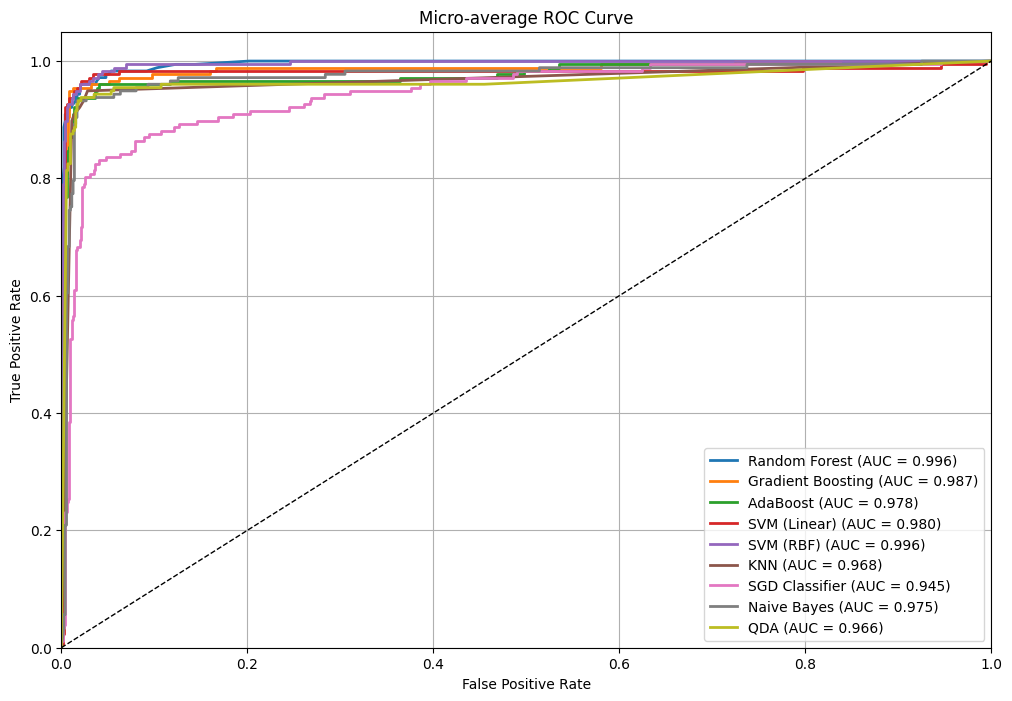

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Number of classes
n_classes = len(np.unique(y_test))

# Binarize test labels
y_test_bin = label_binarize(
    y_test,
    classes=np.unique(y_test)
)

# Define classifiers
models = {
    'Random Forest': RandomForestClassifier(random_state=1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=1),
    'AdaBoost': AdaBoostClassifier(random_state=1),
    'SVM (Linear)': SVC(kernel='linear', probability=True),
    'SVM (RBF)': SVC(kernel='rbf', probability=True),
    'KNN': KNeighborsClassifier(),
    'SGD Classifier': SGDClassifier(random_state=1),
    'Naive Bayes': GaussianNB(),
    'QDA': QuadraticDiscriminantAnalysis()
}

plt.figure(figsize=(12, 8))

for name, model in models.items():

    # Train on SMOTE-balanced training data
    model.fit(X_train_selected, y_train)

    # Prediction scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_selected)

    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_selected)

        if y_score.ndim == 1:
            y_score = np.vstack([-y_score, y_score]).T

    else:
        continue

    # Micro-average ROC
    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_score.ravel()
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{name} (AUC = {roc_auc:.3f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-average ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

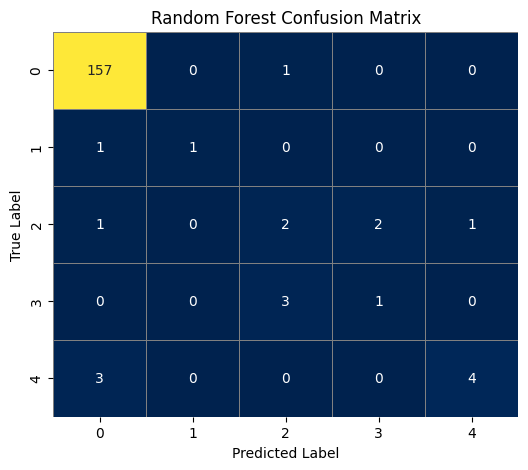

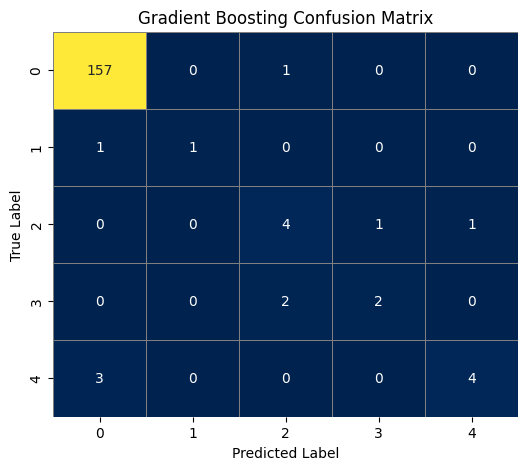

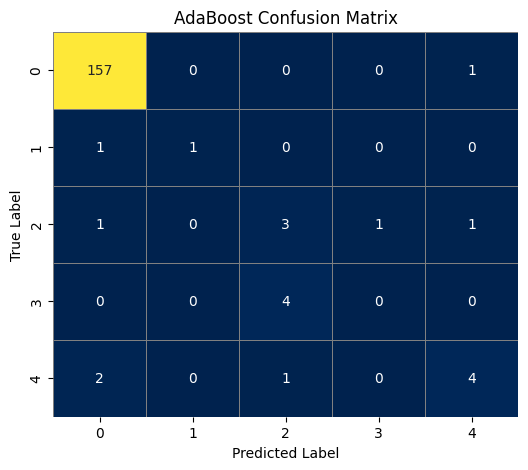

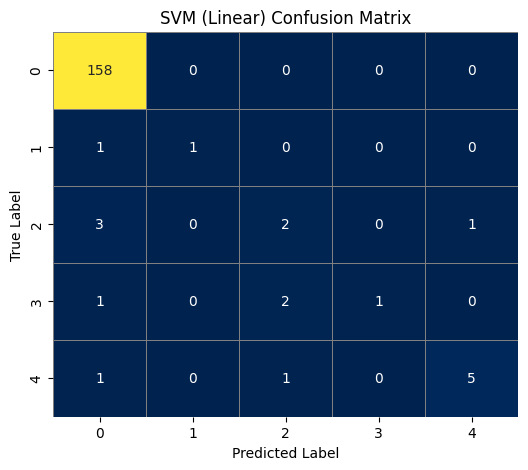

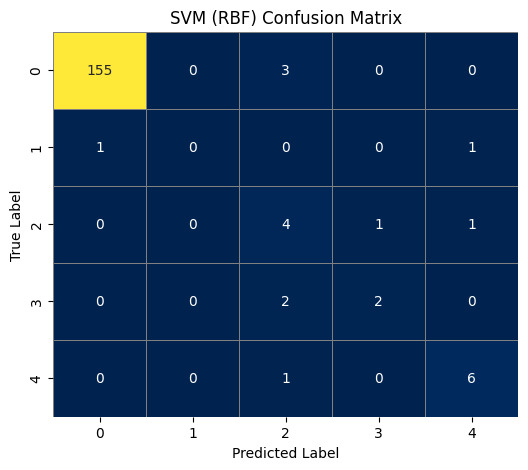

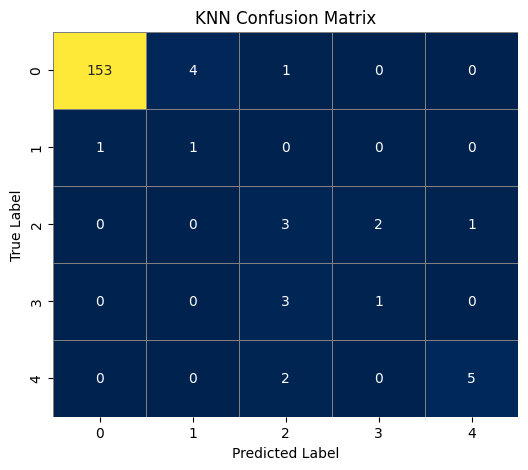

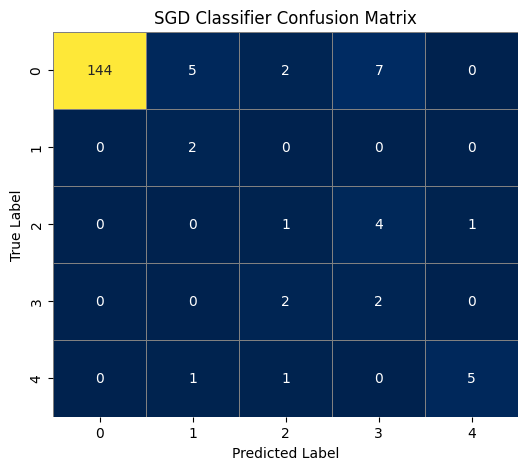

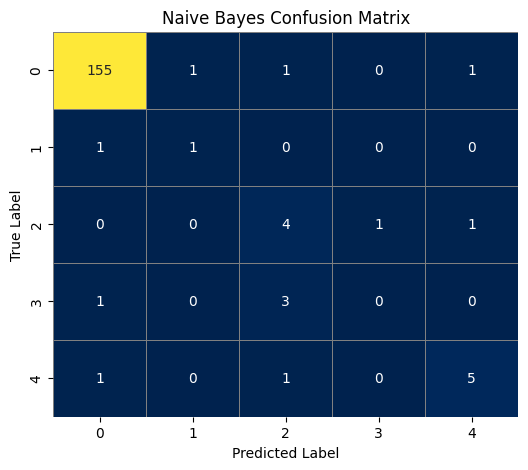

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


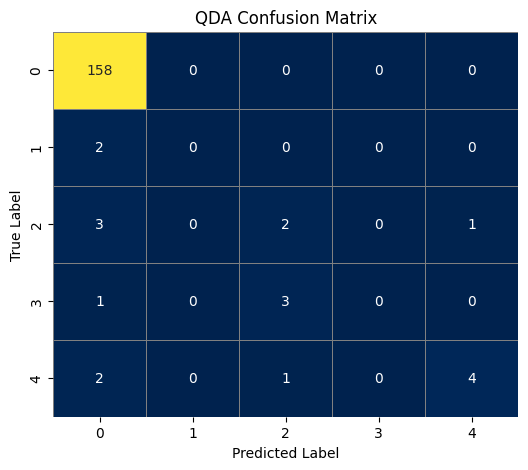

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py", line 669, in fit
    y = self._encode_y(y=y, sample_weig

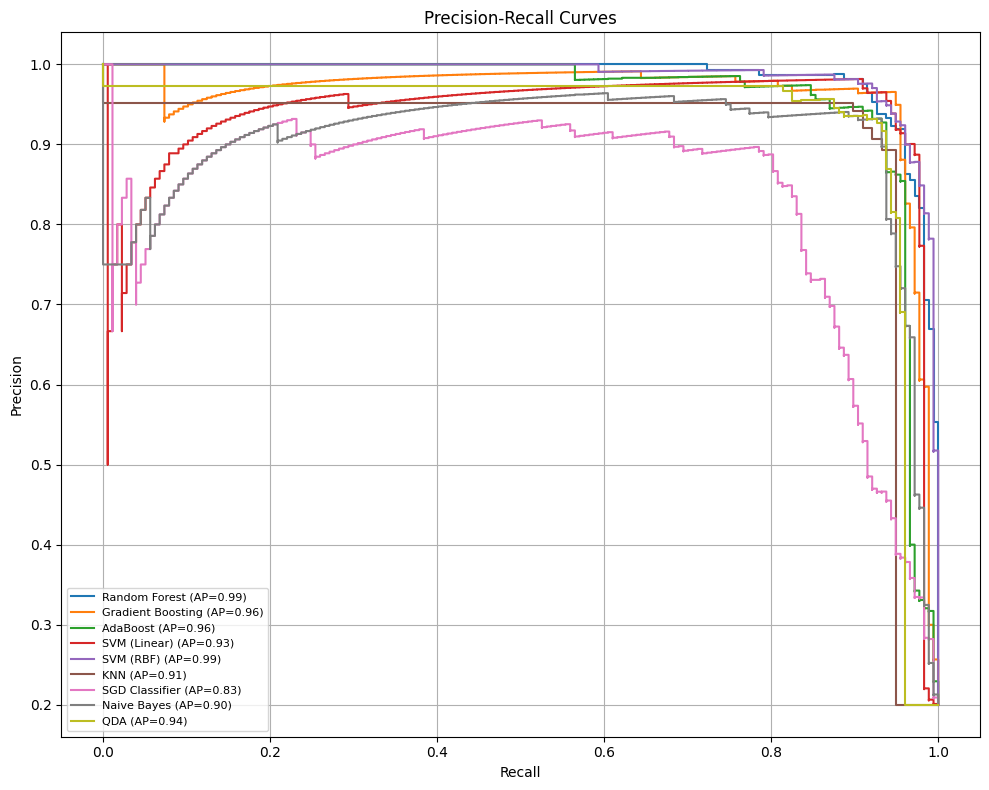

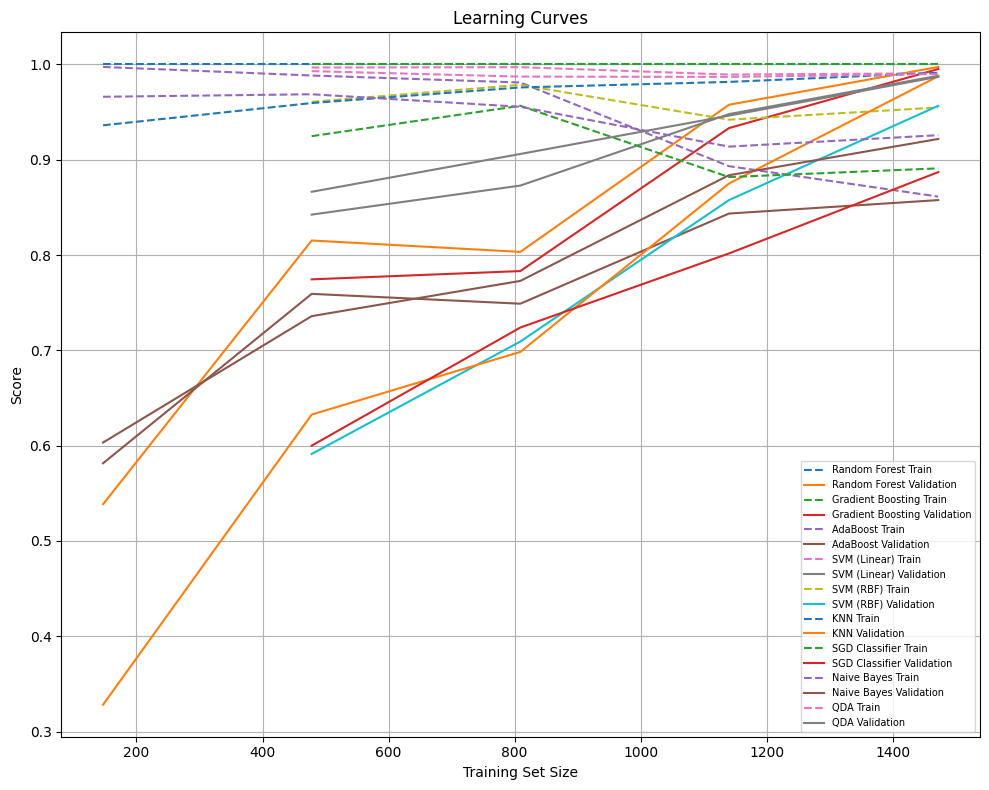

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix
)
from sklearn.model_selection import learning_curve

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Number of classes
n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(
    y_test,
    classes=np.unique(y_test)
)

models = {
    'Random Forest': RandomForestClassifier(random_state=1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=1),
    'AdaBoost': AdaBoostClassifier(random_state=1),
    'SVM (Linear)': SVC(kernel='linear', probability=True),
    'SVM (RBF)': SVC(kernel='rbf', probability=True),
    'KNN': KNeighborsClassifier(),
    'SGD Classifier': SGDClassifier(random_state=1),
    'Naive Bayes': GaussianNB(),
    'QDA': QuadraticDiscriminantAnalysis()
}

# ==========================
# Confusion Matrices
# ==========================
for name, model in models.items():

    model.fit(X_train_selected, y_train)

    y_pred = model.predict(X_test_selected)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='cividis',
        cbar=False,
        linewidths=0.5,
        linecolor='gray'
    )

    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# ==========================
# Combined PR and Learning Curves
# ==========================
fig_pr, ax_pr = plt.subplots(figsize=(10,8))
fig_lc, ax_lc = plt.subplots(figsize=(10,8))

for name, model in models.items():

    model.fit(X_train_selected, y_train)

    # Precision-Recall curves
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_selected)

    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_selected)

        if y_score.ndim == 1:
            y_score = np.vstack(
                [-y_score, y_score]
            ).T
    else:
        continue

    precision, recall, _ = precision_recall_curve(
        y_test_bin.ravel(),
        y_score.ravel()
    )

    avg_prec = average_precision_score(
        y_test_bin,
        y_score,
        average="micro"
    )

    ax_pr.step(
        recall,
        precision,
        where='post',
        label=f'{name} (AP={avg_prec:.2f})'
    )

    # Learning curves
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train_selected,
        y_train,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    ax_lc.plot(
        train_sizes,
        np.mean(train_scores, axis=1),
        '--',
        label=f'{name} Train'
    )

    ax_lc.plot(
        train_sizes,
        np.mean(val_scores, axis=1),
        '-',
        label=f'{name} Validation'
    )

# Precision-Recall plot
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curves')
ax_pr.legend(loc='lower left', fontsize=8)
ax_pr.grid(True)

# Learning Curve plot
ax_lc.set_xlabel('Training Set Size')
ax_lc.set_ylabel('Score')
ax_lc.set_title('Learning Curves')
ax_lc.legend(loc='best', fontsize=7)
ax_lc.grid(True)

fig_pr.tight_layout()
fig_lc.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# Modify according to your label order if necessary
class_names = [
    'Blood Donor',
    'Suspect Blood Donor',
    'Hepatitis',
    'Fibrosis',
    'Cirrhosis'
]

# Macro specificity
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specificity_per_class = []

    for i in range(len(cm)):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)

        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificity_per_class.append(specificity)

    return np.mean(specificity_per_class)


# Class-wise specificity
def classwise_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specificity = []

    for i in range(len(cm)):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)

        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificity.append(spec)

    return specificity


# 5-fold CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

for name, model in models.items():

    acc_scores = []
    prec_scores = []
    rec_scores = []
    spec_scores = []
    f1_scores = []
    mcc_scores = []

    all_y_true = []
    all_y_pred = []

    for train_idx, test_idx in cv.split(X, y):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Feature selection inside fold
        selector = SelectKBest(
            score_func=f_classif,
            k=9
        )

        X_train = selector.fit_transform(
            X_train,
            y_train
        )

        X_test = selector.transform(
            X_test
        )

        # SMOTE inside fold only
        min_class = y_train.value_counts().min()

        k_smote = max(
            1,
            min(2, min_class - 1)
        )

        sm = SMOTE(
            random_state=1,
            k_neighbors=k_smote
        )

        X_train, y_train = sm.fit_resample(
            X_train,
            y_train
        )

        # Train model
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Store predictions
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

        # Store fold metrics
        acc_scores.append(
            accuracy_score(y_test, y_pred)
        )

        prec_scores.append(
            precision_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            )
        )

        spec_scores.append(
            specificity_score(
                y_test,
                y_pred
            )
        )

        f1_scores.append(
            f1_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            )
        )

        mcc_scores.append(
            matthews_corrcoef(
                y_test,
                y_pred
            )
        )

    print("\n" + "="*80)
    print(name)
    print("="*80)

    print(f"Accuracy   : {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
    print(f"Precision  : {np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
    print(f"Sensitivity: {np.mean(rec_scores):.4f} ± {np.std(rec_scores):.4f}")
    print(f"Specificity: {np.mean(spec_scores):.4f} ± {np.std(spec_scores):.4f}")
    print(f"F1 Score   : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
    print(f"MCC        : {np.mean(mcc_scores):.4f} ± {np.std(mcc_scores):.4f}")

    # Class-wise metrics across all folds
    report = classification_report(
        all_y_true,
        all_y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()

    report_df = report_df.loc[
        class_names,
        ['precision', 'recall', 'f1-score', 'support']
    ]

    report_df['specificity'] = classwise_specificity(
        all_y_true,
        all_y_pred
    )

    report_df.columns = [
        'Precision',
        'Sensitivity',
        'F1-Score',
        'Support',
        'Specificity'
    ]

    print("\nClass-wise Results:")
    print(report_df.round(4))


Random Forest
Accuracy   : 0.9439 ± 0.0129
Precision  : 0.5971 ± 0.1115
Sensitivity: 0.5974 ± 0.0925
Specificity: 0.9520 ± 0.0265
F1 Score   : 0.5756 ± 0.0837
MCC        : 0.7049 ± 0.0769

Class-wise Results:
                     Precision  Sensitivity  F1-Score  Support  Specificity
Blood Donor             0.9757       0.9905    0.9830    526.0       0.7937
Suspect Blood Donor     0.5000       0.4286    0.4615      7.0       0.9948
Hepatitis               0.5263       0.5000    0.5128     20.0       0.9842
Fibrosis                0.2857       0.1667    0.2105     12.0       0.9913
Cirrhosis               0.8696       0.8333    0.8511     24.0       0.9947

Gradient Boosting
Accuracy   : 0.9490 ± 0.0163
Precision  : 0.5956 ± 0.0575
Sensitivity: 0.5991 ± 0.0557
Specificity: 0.9669 ± 0.0161
F1 Score   : 0.5884 ± 0.0553
MCC        : 0.7348 ± 0.0943

Class-wise Results:
                     Precision  Sensitivity  F1-Score  Support  Specificity
Blood Donor             0.9849       0.9924 

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p